# Sandbox for Mini-Project 1

In [171]:
import datetime
from pathlib import Path
from typing import List
import pandas as pd


def extract_m15_close_prices(
    base_path: str, symbol: str, start_date: str, end_date: str, rule: str = '15min'
) -> pd.DataFrame:
  """Extracts and resamples tick data from target day Parquet files to M15 close.

  This function identifies and loads only the required Parquet files based on
  the requested date range, saving memory and processing time.

  Args:
    base_path: The root directory string containing the trading data.
    symbol: The financial instrument ticker string (e.g., 'EURUSD').
    start_date: The start timestamp string of the period.
    end_date: The end timestamp string of the period.

  Returns:
    A pandas DataFrame with exactly two columns: 'date' and 'close_price'.
    Returns an empty DataFrame with correct columns if no data is found.
  """
  directory_path = Path(base_path) / 'data' / symbol / 'raw'
  if not directory_path.exists():
    print(f"Directory does not exist: {directory_path}")
    return pd.DataFrame(columns=['date', 'close_price'])

  # Generate the list of dates between start and end to target exact files
  start_dt = pd.to_datetime(start_date).date()
  end_dt = pd.to_datetime(end_date).date()

  # Create a range of daily dates
  date_range = pd.date_range(start=start_dt, end=end_dt, freq='D')

  all_chunks: List[pd.DataFrame] = []
  columns_to_load: List[str] = ['timestamp', 'price_mid']

  for current_date in date_range:
    # Format matching: EURUSD_TICKS_YYYY_MM_DD.parquet
    file_name = f"{symbol}_TICKS_{current_date.strftime('%Y_%m_%d')}.parquet"
    file_path = directory_path / file_name

    # print(f'file_name = {file_name}')
    # print(f'file_path = {file_path}')

    # Only load the file if it exists (handles weekends or missing days safely)
    if file_path.is_file():
      df_chunk = pd.read_parquet(file_path, columns=columns_to_load)

      if not pd.api.types.is_datetime64_any_dtype(df_chunk['timestamp']):
        df_chunk['timestamp'] = pd.to_datetime(df_chunk['timestamp'])

      # Slice the chunk to strictly respect the time range constraints
      date_mask = (df_chunk['timestamp'] >= start_date) & (
          df_chunk['timestamp'] <= end_date
      )
      filtered_chunk = df_chunk.loc[date_mask]

      if not filtered_chunk.empty:
        all_chunks.append(filtered_chunk)

  if not all_chunks:
    print(f"No data found for {symbol} between {start_date} and {end_date}.")
    return pd.DataFrame(columns=['date', 'close_price'])

  df_merged = pd.concat(all_chunks, ignore_index=True)

  # Prepare index for chronological resampling
  df_merged.set_index('timestamp', inplace=True)
  df_merged.sort_index(inplace=True)

  # Resample to 15-minute intervals and pick the last tick as the close price
  df_m15 = df_merged['price_mid'].resample(rule).last()
  # df_m15 = df_merged['price_mid'].resample('1h').last()
  df_m15 = df_m15.dropna()

  # Structure output to match requirements
  df_final = df_m15.reset_index()
  df_final.columns = ['date', 'close_price']

  return df_final


In [96]:
df_eurusd = extract_m15_close_prices(
    base_path='/home/user/perso/trading/alphalab',
    symbol='EURUSD',
    start_date='2020-01-05', # start on sunday
    end_date='2020-01-11', # saturday excluded.
)
df_gbpusd = extract_m15_close_prices(
    base_path='/home/user/perso/trading/alphalab',
    symbol='GBPUSD',
    start_date='2020-01-05',
    end_date='2020-01-11',
)

In [19]:
import pandas as pd


def merge_trading_pair_prices(
    df_x: pd.DataFrame, df_y: pd.DataFrame
) -> pd.DataFrame:
  """Merges two financial asset series into a synchronized pair DataFrame.

  This function performs an inner join on the 'date' column to align prices
  chronologically. It renames the close prices to 'x_close' and 'y_close'
  to prepare the dataset for mean reversion analysis.

  Args:
    df_x: A pandas DataFrame for asset X (e.g., EURUSD) containing 'date' and
      'close_price' columns.
    df_y: A pandas DataFrame for asset Y (e.g., GBPUSD) containing 'date' and
      'close_price' columns.

  Returns:
    A synchronized pandas DataFrame with columns: ['date', 'x_close', 'y_close']
    ordered chronologically.
  """
  # Perform an inner merge to ensure alignment on exact timestamps
  df_merged = pd.merge(df_x, df_y, on='date', how='inner')

  # Rename columns to standard pair trading notation
  df_merged.columns = ['date', 'x_close', 'y_close']

  # Sort by date to maintain chronological order
  df_merged.sort_values(by='date', inplace=True)
  df_merged.reset_index(drop=True, inplace=True)

  return df_merged

In [20]:
df = merge_trading_pair_prices(df_eurusd, df_gbpusd)

In [21]:
df

,date,x_close,y_close
0,2020-01-05 22:00:00,1.116335,1.307215
1,2020-01-05 22:15:00,1.116090,1.307450
2,2020-01-05 22:30:00,1.116130,1.307405
3,2020-01-05 22:45:00,1.115975,1.307235
4,2020-01-05 23:00:00,1.116395,1.307565
...,...,...,...
475,2020-01-10 20:45:00,1.112115,1.305580
476,2020-01-10 21:00:00,1.112065,1.305595
477,2020-01-10 21:15:00,1.112020,1.305580
478,2020-01-10 21:30:00,1.112225,1.305710


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import display


def stream_pair_trading_market(
    df_pair: pd.DataFrame, title: str = 'Pair Trading Setup'
) -> None:
  """Streams asset prices and their correlation scatter using a single color.

  Args:
    df_pair: A pandas DataFrame containing columns: ['date', 'x_close',
      'y_close'].
    title: The title string of the matplotlib figure.
  """
  total_frames = len(df_pair)
  if total_frames == 0:
    print('No data available to animate.')
    return

  name_x = 'EURUSD'
  name_y = 'GBPUSD'

  dates = df_pair['date'].to_numpy()
  asset_x = df_pair['x_close'].to_numpy()
  asset_y = df_pair['y_close'].to_numpy()

  # Identify unique day transition timestamps to draw vertical lines efficiently
  # Extract the clean date part from the datetime objects
  dates_series = pd.Series(dates)
  day_dates = dates_series.dt.date

  # Find indices where the day changes compared to the previous row
  day_changes = day_dates != day_dates.shift()
  day_change_indices = set(day_changes[day_changes].index)

  # Set up a clean, high-performance plot layer with 2/3 and 1/3 layout ratios
  fig, (ax_x, ax_scatter) = plt.subplots(
      nrows=1,
      ncols=2,
      figsize=(16, 6),
      gridspec_kw={'width_ratios': [2, 1]},
  )
  ax_y = ax_x.twinx()

  # Configure boundaries for Primary Axis (Asset X / EURUSD)
  ax_x.set_xlim(dates[0], dates[-1])
  y_min_x = asset_x.min() * 0.999
  y_max_x = asset_x.max() * 1.001
  ax_x.set_ylim(y_min_x, y_max_x)
  ax_x.set_ylabel(f'{name_x} Price', color='dodgerblue', fontweight='bold')
  ax_x.tick_params(axis='y', labelcolor='dodgerblue')

  # Configure boundaries for Secondary Axis (Asset Y / GBPUSD)
  y_min_y = asset_y.min() * 0.999
  y_max_y = asset_y.max() * 1.001
  ax_y.set_ylim(y_min_y, y_max_y)
  ax_y.set_ylabel(f'{name_y} Price', color='orange', fontweight='bold')
  ax_y.tick_params(axis='y', labelcolor='orange')

  ax_x.set_title(title, fontsize=12)
  ax_x.grid(True, linestyle='--', alpha=0.15)
  fig.autofmt_xdate()

  # Configure boundaries for Scatter Plot
  ax_scatter.set_xlim(y_min_x, y_max_x)
  ax_scatter.set_ylim(y_min_y, y_max_y)
  ax_scatter.set_xlabel(name_x, fontweight='bold')
  ax_scatter.set_ylabel(name_y, fontweight='bold')
  ax_scatter.set_title('Price Correlation Scatter', fontsize=12)
  ax_scatter.grid(True, linestyle='--', alpha=0.15)

  # Initialize graphic lines and lead brush tips on their respective axes
  line_x, = ax_x.plot([], [], color='dodgerblue', linewidth=2.0, label=name_x)
  tip_x, = ax_x.plot([], [], color='navy', marker='o', markersize=6)

  line_y, = ax_y.plot([], [], color='orange', linewidth=2.0, label=name_y)
  tip_y, = ax_y.plot([], [], color='darkorange', marker='o', markersize=6)

  # Combine legends from both axes into a single box placed at upper right
  lines = [line_x, line_y]
  labels = [l.get_label() for l in lines]
  ax_x.legend(lines, labels, loc='upper right')

  # Pre-allocate scatter cloud structure with a uniform color (royalblue)
  scatter_plot = ax_scatter.scatter([], [], s=15, color='royalblue', alpha=0.6)

  # History accumulators for the sequential loop
  dates_history = []
  x_history = []
  y_history = []

  try:
    for i in range(total_frames):
      current_date = dates[i]
      current_x = asset_x[i]
      current_y = asset_y[i]

      dates_history.append(current_date)
      x_history.append(current_x)
      y_history.append(current_y)

      # Dynamically add a subtle vertical divider when a new day starts
      # Skip index 0 to avoid drawing a line at the very left border
      if i in day_change_indices and i > 0:
        ax_x.axvline(
            x=current_date, color='gray', linestyle=':', alpha=0.4, linewidth=1
        )

      # Fast array updates without tearing down the underlying axis layout
      line_x.set_data(dates_history, x_history)
      tip_x.set_data([current_date], [current_x])

      line_y.set_data(dates_history, y_history)
      tip_y.set_data([current_date], [current_y])

      # Fast scatter cloud updates using NumPy array stacking
      scatter_points = np.column_stack((x_history, y_history))
      scatter_plot.set_offsets(scatter_points)

      # Force notebook output update as fast as the kernel can compute
      display.clear_output(wait=True)
      display.display(fig)

    print('[INFO] Simulation completed successfully.')

  except KeyboardInterrupt:
    print('\n[INFO] Pair trading simulation stopped by user.')
  finally:
    plt.close(fig)


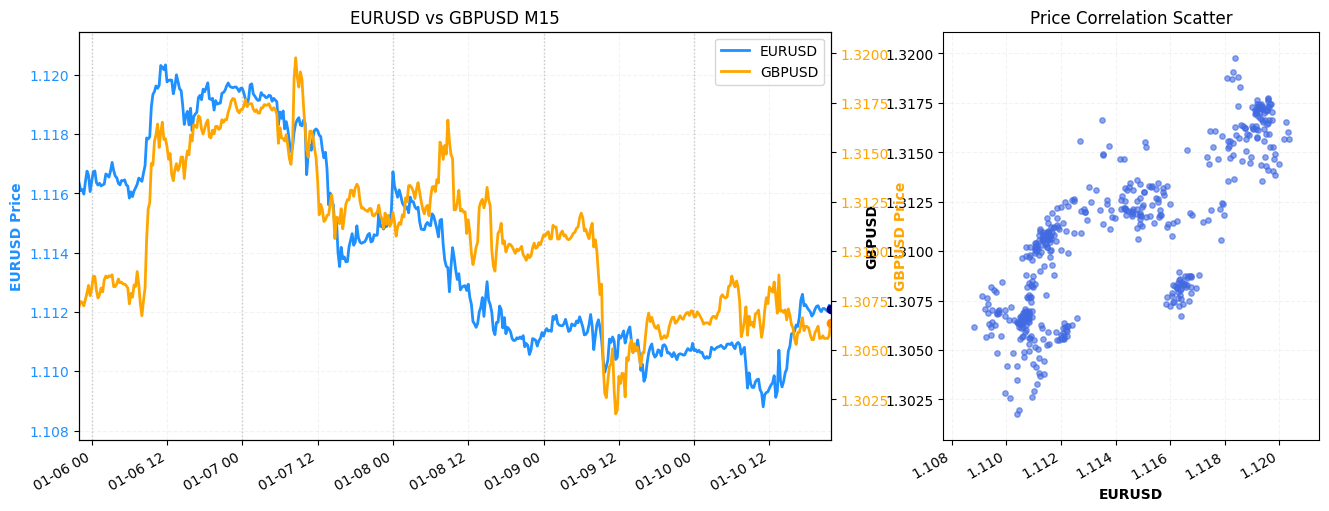

[INFO] Simulation completed successfully.


In [41]:
# --- Example Usage inside your Notebook ---
stream_pair_trading_market(df_pair=df, title="EURUSD vs GBPUSD M15")

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython import display


def stream_pair_trading_market(
    df_pair: pd.DataFrame, title: str = 'Pair Trading Setup'
) -> None:
  """Streams asset prices and their raw price spread dynamically.

  Uses a vertical stack with a 2/3 (prices) and 1/3 (spread) height ratio.
  The bottom panel computes and draws the raw price difference in real-time.

  Args:
    df_pair: A pandas DataFrame containing columns: ['date', 'x_close',
      'y_close'].
    title: The title string of the matplotlib figure.
  """
  total_frames = len(df_pair)
  if total_frames == 0:
    print('No data available to animate.')
    return

  name_x = 'EURUSD'
  name_y = 'GBPUSD'

  dates = df_pair['date'].to_numpy()
  asset_x = df_pair['x_close'].to_numpy()
  asset_y = df_pair['y_close'].to_numpy()

  # Calculate the raw spread: Asset X minus Asset Y
  raw_spread = asset_x - asset_y

  # Identify unique day transition timestamps to draw vertical lines efficiently
  dates_series = pd.Series(dates)
  day_dates = dates_series.dt.date
  day_changes = day_dates != day_dates.shift()
  day_change_indices = set(day_changes[day_changes].index)

  # Create a layout with 2 rows and 1 column using 2/3 and 1/3 height ratios
  # FIXED: Added [2, 1] to specify the correct height proportions
  fig, (ax_line_x, ax_spread) = plt.subplots(
      nrows=2,
      ncols=1,
      figsize=(12, 8),
      gridspec_kw={'height_ratios': [2, 1]},
      sharex=True,  # Link both subplots chronologically on the X axis
  )
  ax_line_y = ax_line_x.twinx()

  # Configure boundaries for Top Primary Axis (Asset X / EURUSD)
  ax_line_x.set_xlim(dates[0], dates[-1])
  y_min_x = asset_x.min() * 0.999
  y_max_x = asset_x.max() * 1.001
  ax_line_x.set_ylim(y_min_x, y_max_x)
  ax_line_x.set_ylabel(f'{name_x} Price', color='dodgerblue', fontweight='bold')
  ax_line_x.tick_params(axis='y', labelcolor='dodgerblue')

  # Configure boundaries for Top Secondary Axis (Asset Y / GBPUSD)
  y_min_y = asset_y.min() * 0.999
  y_max_y = asset_y.max() * 1.001
  ax_line_y.set_ylim(y_min_y, y_max_y)
  ax_line_y.set_ylabel(f'{name_y} Price', color='orange', fontweight='bold')
  ax_line_y.tick_params(axis='y', labelcolor='orange')

  ax_line_x.set_title(title, fontsize=12)
  ax_line_x.grid(True, linestyle='--', alpha=0.15)

  # Configure boundaries for Bottom Axis (Raw Spread)
  y_min_spread = raw_spread.min() * (1.001 if raw_spread.min() < 0 else 0.999)
  y_max_spread = raw_spread.max() * (0.999 if raw_spread.max() < 0 else 1.001)
  ax_spread.set_ylim(y_min_spread, y_max_spread)
  ax_spread.set_ylabel('Raw Spread (X - Y)', color='crimson', fontweight='bold')
  ax_spread.set_title('Raw Price Spread History', fontsize=12)
  ax_spread.grid(True, linestyle='--', alpha=0.15)
  fig.autofmt_xdate()

  # Initialize graphic lines and lead brush tips for the price chart
  line_x, = ax_line_x.plot([], [], color='dodgerblue', linewidth=2.0, label=name_x)
  tip_x, = ax_line_x.plot([], [], color='navy', marker='o', markersize=6)

  line_y, = ax_line_y.plot([], [], color='orange', linewidth=2.0, label=name_y)
  tip_y, = ax_line_y.plot([], [], color='darkorange', marker='o', markersize=6)

  # Initialize graphic line and lead brush tip for the spread chart
  line_spread, = ax_spread.plot([], [], color='crimson', linewidth=1.5, label='Spread')
  tip_spread, = ax_spread.plot([], [], color='darkred', marker='o', markersize=5)

  # Combine legends for the price chart
  lines = [line_x, line_y]
  labels = [l.get_label() for l in lines]
  ax_line_x.legend(lines, labels, loc='upper right')

  # History accumulators for the sequential loop
  dates_history = []
  x_history = []
  y_history = []
  spread_history = []

  try:
    for i in range(total_frames):
      current_date = dates[i]
      current_x = asset_x[i]
      current_y = asset_y[i]
      current_spread = raw_spread[i]

      dates_history.append(current_date)
      x_history.append(current_x)
      y_history.append(current_y)
      spread_history.append(current_spread)

      # Dynamically add subtle vertical dividers to BOTH charts when a new day starts
      if i in day_change_indices and i > 0:
        ax_line_x.axvline(
            x=current_date, color='gray', linestyle=':', alpha=0.4, linewidth=1
        )
        ax_spread.axvline(
            x=current_date, color='gray', linestyle=':', alpha=0.4, linewidth=1
        )

      # Fast array updates for the top price chart
      line_x.set_data(dates_history, x_history)
      tip_x.set_data([current_date], [current_x])

      line_y.set_data(dates_history, y_history)
      tip_y.set_data([current_date], [current_y])

      # Fast array updates for the bottom spread chart
      line_spread.set_data(dates_history, spread_history)
      tip_spread.set_data([current_date], [current_spread])

      # Force notebook output update as fast as the kernel can compute
      display.clear_output(wait=True)
      display.display(fig)

    print('[INFO] Simulation completed successfully.')

  except KeyboardInterrupt:
    print('\n[INFO] Pair trading simulation stopped by user.')
  finally:
    plt.close(fig)


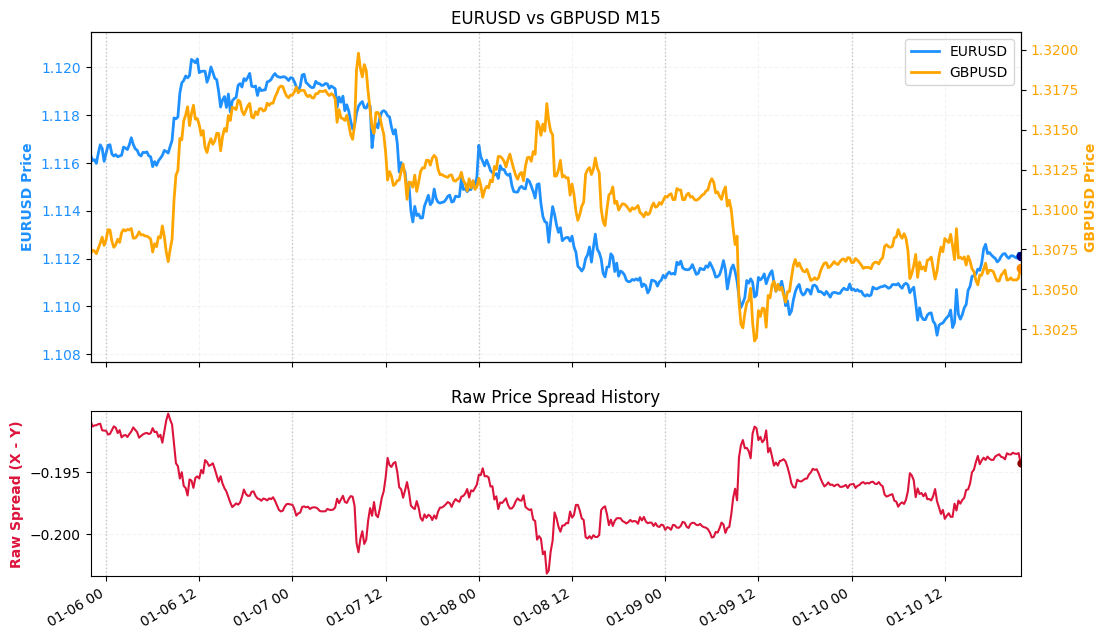

[INFO] Simulation completed successfully.


In [44]:
# --- Example Usage inside your Notebook ---
stream_pair_trading_market(df_pair=df, title="EURUSD vs GBPUSD M15")

In [45]:
df

,date,x_close,y_close
0,2020-01-05 22:00:00,1.116335,1.307215
1,2020-01-05 22:15:00,1.116090,1.307450
2,2020-01-05 22:30:00,1.116130,1.307405
3,2020-01-05 22:45:00,1.115975,1.307235
4,2020-01-05 23:00:00,1.116395,1.307565
...,...,...,...
475,2020-01-10 20:45:00,1.112115,1.305580
476,2020-01-10 21:00:00,1.112065,1.305595
477,2020-01-10 21:15:00,1.112020,1.305580
478,2020-01-10 21:30:00,1.112225,1.305710


In [56]:
import numpy as np
import pandas as pd


def compute_pair_trading_metrics(
    df_pair: pd.DataFrame, window: int = 60
) -> pd.DataFrame:
  """Computes rolling linear regression and stats using a one-pass algorithm.

  Replicates the exact algebraic formulas of the provided fit method inside a
  rolling window context (T = window).

  Args:
    df_pair: A pandas DataFrame containing columns: ['x_close', 'y_close'].
    window: The lookback period (T) for the rolling calculations. Default is 60.

  Returns:
    A copy of the DataFrame with the calculated pair trading metrics added.
  """
  df = df_pair.copy()
  t = window

  if t < 3:
    print("[ERROR] Window size must be at least 3.")
    return df

  # Extract raw series
  x = df['x_close']
  y = df['y_close']

  # 1. Accumulate historical rolling sums
  sum_x = x.rolling(window=t).sum()
  sum_y = y.rolling(window=t).sum()

  sum_x2 = (x ** 2).rolling(window=t).sum()
  sum_y2 = (y ** 2).rolling(window=t).sum()
  sum_xy = (x * y).rolling(window=t).sum()

  # Compute rolling means from sums
  mean_x = sum_x / t
  mean_y = sum_y / t

  # 2. Compute the shared common denominator
  denominator = t * sum_x2 - (sum_x ** 2)

  # 3. Compute optimal slope (Hedge Ratio)
  df['hedge_ratio'] = ((t * sum_xy) - (sum_x * sum_y)) / denominator

  # 4. Compute optimal intercept using developed sums formula
  df['intercept'] = ((sum_y * sum_x2) - (sum_x * sum_xy)) / denominator

  # 5. Compute Unbiased Residual Sum of Squares (RSS) and Volatility (sigma_e)
  # RSS: (sum(y^2) - T * mean_y^2) - coef * (sum(xy) - T * mean_x * mean_y)
  rss = (sum_y2 - (t * (mean_y ** 2))) - df['hedge_ratio'] * (
      sum_xy - t * mean_x * mean_y
  )

  # Safety filter against floating-point precision drift
  rss = rss.clip(lower=0.0)

  # Total Sum of Squares (TSS) & Explained Sum of Squares (ESS) for metrics completeness
  # TSS: sum(y^2) - T * mean_y^2
  df['tss'] = sum_y2 - (t * (mean_y ** 2))
  df['tss'] = df['tss'].clip(lower=0.0)

  # ESS: TSS - RSS
  df['ess'] = (df['tss'] - rss).clip(lower=0.0)
  df['rss'] = rss

  # Formula Sigma: sqrt(RSS / (T - 2))
  df['sigma_e'] = np.sqrt(df['rss'] / (t - 2))

  # 6. Compute current Spread and Z-Score
  # Current spread value at each timestamp: Y - (Hedge * X + Intercept)
  df['spread'] = y - (df['hedge_ratio'] * x + df['intercept'])

  # Z-score = current spread / rolling sigma
  df['z_score'] = df['spread'] / df['sigma_e'].replace(0, np.nan)

  return df.dropna()


In [57]:
result = compute_pair_trading_metrics(df, window=10)
result

,date,x_close,y_close,hedge_ratio,intercept,tss,ess,rss,sigma_e,spread,z_score
9,2020-01-06 00:15:00,1.116725,1.308730,1.293864,-0.136640,2.157950e-06,1.185988e-06,9.719619e-07,0.000349,0.000480,1.376005
10,2020-01-06 00:30:00,1.116755,1.308715,1.443220,-0.303283,2.547950e-06,1.787031e-06,7.609190e-07,0.000308,0.000275,0.892784
11,2020-01-06 00:45:00,1.116365,1.308020,1.420953,-0.278407,2.315960e-06,1.538806e-06,7.771535e-07,0.000312,0.000125,0.400266
12,2020-01-06 01:00:00,1.116280,1.307630,1.384737,-0.237973,2.108622e-06,1.335963e-06,7.726593e-07,0.000311,-0.000151,-0.486177
13,2020-01-06 01:15:00,1.116340,1.307800,1.275805,-0.116348,1.543340e-06,7.879755e-07,7.553645e-07,0.000307,-0.000084,-0.273258
...,...,...,...,...,...,...,...,...,...,...,...
475,2020-01-10 20:45:00,1.112115,1.305580,1.606961,-0.481298,4.773000e-07,2.786068e-07,1.986932e-07,0.000158,-0.000247,-1.565857
476,2020-01-10 21:00:00,1.112065,1.305595,1.678144,-0.560485,4.948100e-07,2.940360e-07,2.007740e-07,0.000158,-0.000125,-0.786736
477,2020-01-10 21:15:00,1.112020,1.305580,2.288352,-1.239108,4.757525e-07,3.205294e-07,1.552231e-07,0.000139,-0.000004,-0.030983
478,2020-01-10 21:30:00,1.112225,1.305710,1.979534,-0.895716,4.290125e-07,2.000814e-07,2.289311e-07,0.000169,-0.000261,-1.544211


In [58]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython import display


def stream_pair_trading_market(
    df_pair: pd.DataFrame, title: str = 'Pair Trading Setup'
) -> None:
  """Streams asset prices and their dynamic Z-Score inside a Jupyter Notebook.

  Uses a vertical subplots arrangement. The top panel handles dual-axes price
  lines while the bottom panel captures the rolling Z-Score with trigger lines.

  Args:
    df_pair: A pandas DataFrame containing at least: ['date', 'x_close',
      'y_close', 'z_score']. It can optionally include 'x_ma' and 'y_ma'.
    title: The title string of the matplotlib figure.
  """
  total_frames = len(df_pair)
  if total_frames == 0:
    print('No data available to animate.')
    return

  name_x = 'EURUSD'
  name_y = 'GBPUSD'

  dates = df_pair['date'].to_numpy()
  asset_x = df_pair['x_close'].to_numpy()
  asset_y = df_pair['y_close'].to_numpy()
  z_score = df_pair['z_score'].to_numpy()

  # Identify optional pre-calculated moving averages if present in DataFrame
  has_ma_x = 'x_ma' in df_pair.columns
  has_ma_y = 'y_ma' in df_pair.columns
  ma_x = df_pair['x_ma'].to_numpy() if has_ma_x else None
  ma_y = df_pair['y_ma'].to_numpy() if has_ma_y else None

  # Identify unique day transition timestamps for vertical lines
  dates_series = pd.Series(dates)
  day_dates = dates_series.dt.date
  day_changes = day_dates != day_dates.shift()
  day_change_indices = set(day_changes[day_changes].index)

  # Create a layout with 2 rows and 1 column using 2/3 and 1/3 height ratios
  fig, (ax_line_x, ax_zscore) = plt.subplots(
      nrows=2,
      ncols=1,
      figsize=(12, 8),
      gridspec_kw={'height_ratios': [2, 2]},
      sharex=True,  # Sync X-axis chronologically
  )
  ax_line_y = ax_line_x.twinx()

  # Configure boundaries for Top Primary Axis (Asset X / EURUSD)
  ax_line_x.set_xlim(dates[0], dates[-1])
  y_min_x = asset_x.min() * 0.999
  y_max_x = asset_x.max() * 1.001
  ax_line_x.set_ylim(y_min_x, y_max_x)
  ax_line_x.set_ylabel(f'{name_x} Price', color='dodgerblue', fontweight='bold')
  ax_line_x.tick_params(axis='y', labelcolor='dodgerblue')

  # Configure boundaries for Top Secondary Axis (Asset Y / GBPUSD)
  y_min_y = asset_y.min() * 0.999
  y_max_y = asset_y.max() * 1.001
  ax_line_y.set_ylim(y_min_y, y_max_y)
  ax_line_y.set_ylabel(f'{name_y} Price', color='orange', fontweight='bold')
  ax_line_y.tick_params(axis='y', labelcolor='orange')

  ax_line_x.set_title(title, fontsize=12)
  ax_line_x.grid(True, linestyle='--', alpha=0.15)

  # Configure boundaries for Bottom Axis (Z-Score)
  # Dynamic boundary adjustment with a safety floor at +/- 3.0 for standard dev
  z_min = min(pd.Series(z_score).dropna().min(), -3.0) * 1.1
  z_max = max(pd.Series(z_score).dropna().max(), 3.0) * 1.1
  ax_zscore.set_ylim(z_min, z_max)
  ax_zscore.set_ylabel('Z-Score', color='purple', fontweight='bold')
  ax_zscore.set_title('Rolling Spread Z-Score', fontsize=12)
  ax_zscore.grid(True, linestyle='--', alpha=0.15)
  fig.autofmt_xdate()

  # Static structural thresholds on the Z-Score graph before starting the loop
  ax_zscore.axhline(y=0.0, color='gray', linestyle='-', alpha=0.5, linewidth=1)
  ax_zscore.axhline(y=2.0, color='red', linestyle='--', alpha=0.4, linewidth=1)
  ax_zscore.axhline(y=-2.0, color='green', linestyle='--', alpha=0.4, linewidth=1)

  # Initialize graphic layers for standard price tracks
  line_x, = ax_line_x.plot([], [], color='dodgerblue', linewidth=1.5, label=name_x)
  tip_x, = ax_line_x.plot([], [], color='navy', marker='o', markersize=5)

  line_y, = ax_line_y.plot([], [], color='orange', linewidth=1.5, label=name_y)
  tip_y, = ax_line_y.plot([], [], color='darkorange', marker='o', markersize=5)

  # Conditional layer initialization for moving averages
  line_ma_x = None
  line_ma_y = None
  lines_legend = [line_x, line_y]

  if has_ma_x:
    line_ma_x, = ax_line_x.plot(
        [], [], color='navy', linewidth=1.2, linestyle='--', label=f'{name_x} MA'
    )
    lines_legend.insert(1, line_ma_x)

  if has_ma_y:
    line_ma_y, = ax_line_y.plot(
        [], [], color='darkorange', linewidth=1.2, linestyle='--', label=f'{name_y} MA'
    )
    lines_legend.append(line_ma_y)

  # Initialize dynamic layers for the Z-Score panel
  line_z, = ax_zscore.plot([], [], color='purple', linewidth=1.5, label='Z-Score')
  tip_z, = ax_zscore.plot([], [], color='darkmagenta', marker='o', markersize=5)

  # Combined header legend
  labels_legend = [l.get_label() for l in lines_legend]
  ax_line_x.legend(lines_legend, labels_legend, loc='upper right')

  # History accumulators
  dates_history = []
  x_history = []
  y_history = []
  ma_x_history = []
  ma_y_history = []
  z_history = []

  try:
    for i in range(total_frames):
      current_date = dates[i]
      current_x = asset_x[i]
      current_y = asset_y[i]
      current_z = z_score[i]

      dates_history.append(current_date)
      x_history.append(current_x)
      y_history.append(current_y)
      z_history.append(current_z)

      # Append moving averages if active
      if has_ma_x:
        ma_x_history.append(ma_x[i])
      if has_ma_y:
        ma_y_history.append(ma_y[i])

      # Render vertical daily separators
      if i in day_change_indices and i > 0:
        ax_line_x.axvline(
            x=current_date, color='gray', linestyle=':', alpha=0.4, linewidth=1
        )
        ax_zscore.axvline(
            x=current_date, color='gray', linestyle=':', alpha=0.4, linewidth=1
        )

      # Fast array streaming into the pricing plot layer
      line_x.set_data(dates_history, x_history)
      tip_x.set_data([current_date], [current_x])

      line_y.set_data(dates_history, y_history)
      tip_y.set_data([current_date], [current_y])

      # Fast streaming for moving averages
      if has_ma_x:
        line_ma_x.set_data(dates_history, ma_x_history)
      if has_ma_y:
        line_ma_y.set_data(dates_history, ma_y_history)

      # Fast array streaming into the Z-Score plot layer
      line_z.set_data(dates_history, z_history)
      tip_z.set_data([current_date], [current_z])

      # Flush updates to the notebook display buffer instantly
      display.clear_output(wait=True)
      display.display(fig)

    print('[INFO] Simulation completed successfully.')

  except KeyboardInterrupt:
    print('\n[INFO] Pair trading simulation stopped by user.')
  finally:
    plt.close(fig)


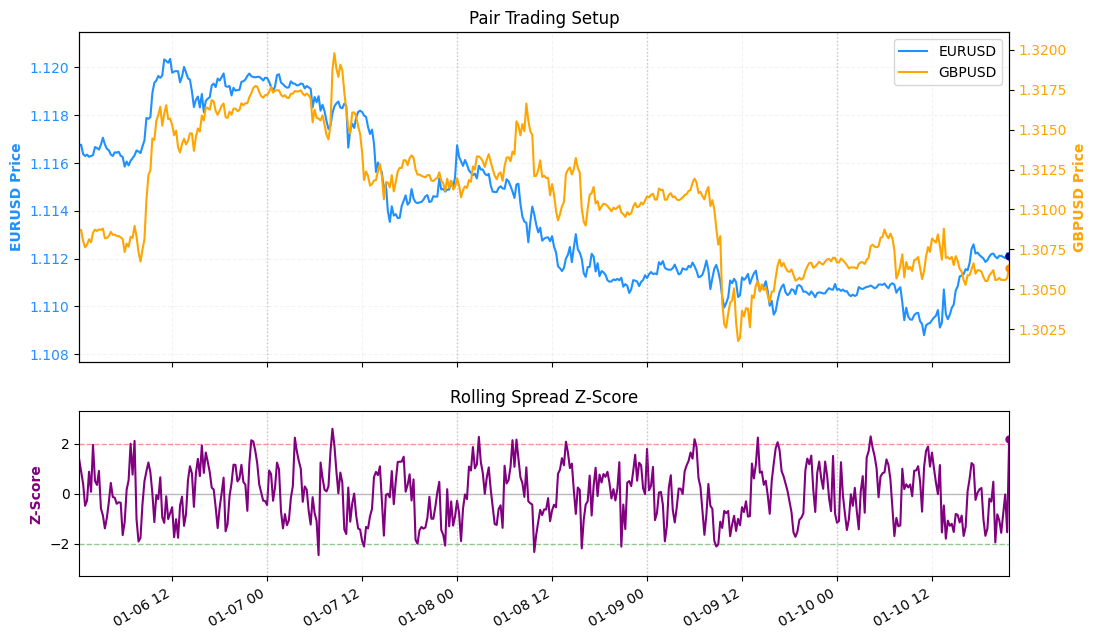

[INFO] Simulation completed successfully.


In [59]:
result = compute_pair_trading_metrics(df, window=10)
stream_pair_trading_market(result)

In [123]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import display


def stream_pair_trading_market(
    df_pair: pd.DataFrame, title: str = 'Pair Trading Strategy'
) -> None:
  """Streams asset prices and colors trade areas on the Z-Score subplot.

  Triggers trades at Z-Score >= 2.0 (colored red/coral) or Z-Score <= -2.0
  (colored green). Closes trades when Z-Score crosses 0.0.

  Args:
    df_pair: A pandas DataFrame containing columns: ['date', 'x_close',
      'y_close', 'z_score'].
    title: The title string of the matplotlib figure.
  """
  total_frames = len(df_pair)
  if total_frames == 0:
    print('No data available to animate.')
    return

  name_x = 'EURUSD'
  name_y = 'GBPUSD'

  dates = df_pair['date'].to_numpy()
  asset_x = df_pair['x_close'].to_numpy()
  asset_y = df_pair['y_close'].to_numpy()
  z_score = df_pair['z_score'].to_numpy()
  hedge_ratio = df_pair['hedge_ratio'].to_numpy()


  # Track optional moving averages
  has_ma_x = 'x_ma' in df_pair.columns
  has_ma_y = 'y_ma' in df_pair.columns
  ma_x = df_pair['x_ma'].to_numpy() if has_ma_x else None
  ma_y = df_pair['y_ma'].to_numpy() if has_ma_y else None

  # Identify unique day transitions for vertical line boundaries
  dates_series = pd.Series(dates)
  day_dates = dates_series.dt.date
  day_changes = day_dates != day_dates.shift()
  day_change_indices = set(day_changes[day_changes].index)

  # Create vertical layout stack (2/3 and 1/3 height ratios)
  # FIXED: Added the explicit list [2, 1] for height_ratios
  fig, (ax_line_x, ax_zscore) = plt.subplots(
      nrows=2,
      ncols=1,
      figsize=(12, 8),
      gridspec_kw={'height_ratios': [1, 2]},
      sharex=True,
  )
  ax_line_y = ax_line_x.twinx()

  # Configure boundaries for Top Panels
  ax_line_x.set_xlim(dates[0], dates[-1])
  ax_line_x.set_ylim(asset_x.min() * 0.999, asset_x.max() * 1.001)
  ax_line_x.set_ylabel(f'{name_x} Price', color='dodgerblue', fontweight='bold')
  ax_line_x.tick_params(axis='y', labelcolor='dodgerblue')

  ax_line_y.set_ylim(asset_y.min() * 0.999, asset_y.max() * 1.001)
  ax_line_y.set_ylabel(f'{name_y} Price', color='orange', fontweight='bold')
  ax_line_y.tick_params(axis='y', labelcolor='orange')

  ax_line_x.set_title(title, fontsize=12, fontweight='bold')
  ax_line_x.grid(True, linestyle='--', alpha=0.15)

  # Configure boundaries for Bottom Z-Score Panel
  z_min = min(pd.Series(z_score).dropna().min(), -2.5) * 1.1
  z_max = max(pd.Series(z_score).dropna().max(), 2.5) * 1.1
  ax_zscore.set_ylim(z_min, z_max)
  ax_zscore.set_ylabel('Z-Score', color='purple', fontweight='bold')
  ax_zscore.grid(True, linestyle='--', alpha=0.15)
  fig.autofmt_xdate()

  # Static threshold lines
  ax_zscore.axhline(y=0.0, color='black', linestyle='-', alpha=0.5, linewidth=1)
  ax_zscore.axhline(y=2.0, color='gray', linestyle='--', alpha=0.6, linewidth=1)
  ax_zscore.axhline(y=-2.0, color='gray', linestyle='--', alpha=0.6, linewidth=1)

  # Initialize asset price artists
  line_x, = ax_line_x.plot([], [], color='dodgerblue', linewidth=1.5, label=name_x)
  tip_x, = ax_line_x.plot([], [], color='navy', marker='o', markersize=5)
  line_y, = ax_line_y.plot([], [], color='orange', linewidth=1.5, label=name_y)
  tip_y, = ax_line_y.plot([], [], color='darkorange', marker='o', markersize=5)

  # Initialize moving average artists if present
  line_ma_x, line_ma_y = None, None
  lines_legend = [line_x, line_y]
  if has_ma_x:
    line_ma_x, = ax_line_x.plot([], [], color='navy', linewidth=1.2, linestyle='--')
  if has_ma_y:
    line_ma_y, = ax_line_y.plot([], [], color='darkorange', linewidth=1.2, linestyle='--')

  # Initialize Z-score artists
  line_z, = ax_zscore.plot([], [], color='purple', linewidth=1.5)
  tip_z, = ax_zscore.plot([], [], color='darkmagenta', marker='o', markersize=5)

  ax_line_x.legend(lines_legend, [name_x, name_y], loc='upper right')

  # History containers for execution loop
  dates_history, x_history, y_history, z_history = [], [], [], []
  ma_x_history, ma_y_history = [], []

  # Strategy engine tracking flags
  in_short_trade, in_long_trade = False, False
  trade_dates, trade_z = [], []
  active_fill = None

  trade_history = []

  try:
    for i in range(total_frames):
      current_date = dates[i]
      current_x = asset_x[i]
      current_y = asset_y[i]
      current_z = z_score[i]

      dates_history.append(current_date)
      x_history.append(current_x)
      y_history.append(current_y)
      z_history.append(current_z)

      if has_ma_x:
        ma_x_history.append(ma_x[i])
      if has_ma_y:
        ma_y_history.append(ma_y[i])

      # Add daily vertical separators
      if i in day_change_indices and i > 0:
        ax_line_x.axvline(x=current_date, color='gray', linestyle=':', alpha=0.4)
        ax_zscore.axvline(x=current_date, color='gray', linestyle=':', alpha=0.4)

      # --- VECTORIZED STATE MACHINE LOGIC ---
      # Check entry rules if currently flat
      if not in_short_trade and not in_long_trade:
        if not np.isnan(current_z):
          if current_z >= 2.0:
            in_short_trade = True
            trade_history.append(f'ENTER SHORT: {current_date} (hedge: {hedge_ratio[i]})')
            trade_dates, trade_z = [current_date], [current_z]
          elif current_z <= -2.0:
            in_long_trade = True
            trade_history.append(f'ENTER LONG: {current_date} (hedge: {hedge_ratio[i]})')
            trade_dates, trade_z = [current_date], [current_z]

      # Accumulate tracking arrays if inside an open market exposure position
      elif in_short_trade or in_long_trade:
        trade_dates.append(current_date)
        trade_z.append(current_z)

        # Check closing conditions (reversion back onto baseline 0.0 center point)
        if (in_short_trade and current_z <= 0.0) or (in_long_trade and current_z >= 0.0):
          # Bake the completed transaction area persistently onto the base layer axis
          fill_color = '#ff6b6b' if in_short_trade else '#51cf66'
          ax_zscore.fill_between(trade_dates, trade_z, 0, color=fill_color, alpha=0.4)

          # Reset tracking variables for the next setup opportunity
          in_short_trade, in_long_trade = False, False
          trade_dates, trade_z = [], []
          active_fill = None

          trade_history[-1] = f'{trade_history[-1]} - CLOSE: {current_date}'

      # --- LAYER RE-RENDERING HANDLERS ---
      # Clear previous live temporary frame brush layer if any
      if active_fill is not None:
        active_fill.remove()
        active_fill = None

      # Redraw dynamic floating fill block if a position remains unresolved
      if len(trade_dates) > 0:
        fill_color = '#ff6b6b' if in_short_trade else '#51cf66'
        active_fill = ax_zscore.fill_between(
            trade_dates, trade_z, 0, color=fill_color, alpha=0.4
        )

      # Stream asset price updates
      line_x.set_data(dates_history, x_history)
      tip_x.set_data([current_date], [current_x])
      line_y.set_data(dates_history, y_history)
      tip_y.set_data([current_date], [current_y])

      if has_ma_x:
        line_ma_x.set_data(dates_history, ma_x_history)
      if has_ma_y:
        line_ma_y.set_data(dates_history, ma_y_history)

      # Stream Z-Score model track line updates
      line_z.set_data(dates_history, z_history)
      tip_z.set_data([current_date], [current_z])

      # Execute display pipeline updates instantly
      display.clear_output(wait=True)
      display.display(fig)

    print('[INFO] Strategy backtest completed successfully.')
    print('\n'.join(trade_history))

  except KeyboardInterrupt:
    print('\n[INFO] Pair trading simulation stopped by user.')
  finally:
    plt.close(fig)


In [124]:
start_dates = ['2026-08-10', '2026-04-05', '2026-07-12', '2021-08-22', '2020-03-08', '2020-01-05']
end_dates = ['2026-08-12', '2026-04-11', '2026-04-18', '2021-08-28', '2020-03-14', '2020-01-11']
start_date = start_dates[0] # '2020-01-05' (nice!)
end_date = end_dates[0] # '2020-01-11' (nice!)

df_eurusd = extract_m15_close_prices(
    base_path='/home/user/perso/trading/alphalab',
    symbol='EURUSD',
    start_date=start_date, # start on sunday
    end_date=end_date, # saturday excluded.
)
df_gbpusd = extract_m15_close_prices(
    base_path='/home/user/perso/trading/alphalab',
    symbol='GBPUSD',
    start_date=start_date,
    end_date=end_date,
)
df = merge_trading_pair_prices(df_eurusd, df_gbpusd)

result = compute_pair_trading_metrics(df, window=10)
stream_pair_trading_market(result)


[INFO] Pair trading simulation stopped by user.


In [107]:
# ENTER SHORT: 2026-08-10T14 --> 9 pips (GBP)
# ENTER LONG: 2026-08-11T11:00:00.000000000 ---> 6.2pips - 15.2 pips =
6.2* 0.77 - 15.2
# ENTER SHORT: 2026-08-12T08:00:00.000000000 (hedge: 0.2595623238002785) - CLOSE: 2026-08-12T12:00:00.000000000 -->
26.4  + 0.0 - 14.8 * 0.25

22.7

# Rolling Windows Trap (Fausse convergence)

Lorsque vous êtes en position et que le spread continue de s'écarter contre vous, la fenêtre glissante intègre ces nouvelles valeurs extrêmes. Mathématiquement, la moyenne glissante augmente et l'écart-type résiduel (\(\sigma _{e}\)) explose. Par conséquent, le Z-score s'écrase artificiellement vers 0 alors que votre perte en euros/dollars augmente dans le monde réel. Le modèle change ses coordonnées pendant que vous êtes au combat.L'approche pro que vous décrivez règle définitivement ce problème en gelant les paramètres à l'entrée


In [176]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import display


def stream_pair_trading_market(
    df_pair: pd.DataFrame, title: str = 'Professional Pair Trading Strategy'
) -> None:
  """Streams asset prices, rolling Z-score, and the delta spread to target.

  Maintains a maximum constant rendering speed by drawing day barriers
  statically before entering the loop.

  Args:
    df_pair: A pandas DataFrame containing pre-calculated metrics: ['date',
      'x_close', 'y_close', 'z_score', 'hedge_ratio', 'intercept', 'spread'].
    title: The title string of the matplotlib figure.
  """
  total_frames = len(df_pair)
  if total_frames == 0:
    print('No data available to animate.')
    return

  name_x = 'EURUSD'
  name_y = 'GBPUSD'

  dates = df_pair['date'].to_numpy()
  asset_x = df_pair['x_close'].to_numpy()
  asset_y = df_pair['y_close'].to_numpy()
  z_score = df_pair['z_score'].to_numpy()

  rolling_betas = df_pair['hedge_ratio'].to_numpy()
  rolling_alphas = df_pair['intercept'].to_numpy()
  rolling_spread = df_pair['spread'].to_numpy()

  # Identify unique day transitions for vertical line boundaries
  dates_series = pd.Series(dates)
  day_dates = dates_series.dt.date
  day_changes = day_dates != day_dates.shift()
  day_change_indices = set(day_changes[day_changes].index)

  # Create a 3-row layout with 2:1:1 height proportions
  fig, (ax_prices, ax_zscore, ax_delta) = plt.subplots(
      nrows=3,
      ncols=1,
      figsize=(12, 10),
      gridspec_kw={'height_ratios': [2,1,1]},
      sharex=True,
  )
  ax_prices_y = ax_prices.twinx()

  # Configure boundaries for Top Panel (Prices)
  ax_prices.set_xlim(dates[0], dates[-1])
  ax_prices.set_ylim(asset_x.min() * 0.999, asset_x.max() * 1.001)
  ax_prices.set_ylabel(f'{name_x} Price', color='dodgerblue', fontweight='bold')
  ax_prices.tick_params(axis='y', labelcolor='dodgerblue')

  ax_prices_y.set_ylim(asset_y.min() * 0.999, asset_y.max() * 1.001)
  ax_prices_y.set_ylabel(f'{name_y} Price', color='orange', fontweight='bold')
  ax_prices_y.tick_params(axis='y', labelcolor='orange')

  ax_prices.set_title(title, fontsize=12, fontweight='bold')
  ax_prices.grid(True, linestyle='--', alpha=0.15)

  # Configure boundaries for Middle Panel (Z-Score)
  z_min = min(pd.Series(z_score).dropna().min(), -2.5) * 1.1
  z_max = max(pd.Series(z_score).dropna().max(), 2.5) * 1.1
  ax_zscore.set_ylim(z_min, z_max)
  ax_zscore.set_ylabel('Z-Score', color='purple', fontweight='bold')
  ax_zscore.grid(True, linestyle='--', alpha=0.15)

  # Middle Panel Thresholds
  ax_zscore.axhline(y=0.0, color='black', linestyle='-', alpha=0.5, linewidth=1)
  ax_zscore.axhline(y=2.0, color='gray', linestyle='--', alpha=0.6, linewidth=1)
  ax_zscore.axhline(y=-2.0, color='gray', linestyle='--', alpha=0.6, linewidth=1)

  # Configure boundaries for Bottom Panel (Delta Spread tracking)
  ax_delta.set_ylabel('Delta Spread', color='crimson', fontweight='bold')
  ax_delta.set_title('Distance to Target (Convergence to 0.0)', fontsize=12)
  # ax_delta.grid(True, linestyle='--', alpha=0.15)
  fig.autofmt_xdate()

  # The profit target line anchored at 0.0
  ax_delta.set_ylim(-2.0, 2.0)
  # ax_delta.axhline(y=0.0, color='darkgreen', linestyle='-', linewidth=2, label='Take Profit (0.0)')
  ax_delta.axhline(y=0.0, color='darkgreen', linestyle='-', linewidth=2, label='Take Profit (0.0)')

  # CRUCIAL PERFORMANCE FIX: Pre-draw daily vertical lines once before the loop
  for idx in sorted(day_change_indices):
    if idx > 0:
      ax_prices.axvline(x=dates[idx], color='gray', linestyle=':', alpha=0.4)
      ax_zscore.axvline(x=dates[idx], color='gray', linestyle=':', alpha=0.4)
      ax_delta.axvline(x=dates[idx], color='gray', linestyle=':', alpha=0.4)

  # Initialize chart artists
  line_x, = ax_prices.plot([], [], color='dodgerblue', linewidth=1.5, label=name_x)
  tip_x, = ax_prices.plot([], [], color='navy', marker='o', markersize=5)
  line_y, = ax_prices_y.plot([], [], color='orange', linewidth=1.5, label=name_y)
  tip_y, = ax_prices_y.plot([], [], color='darkorange', marker='o', markersize=5)

  line_z, = ax_zscore.plot([], [], color='purple', linewidth=1.5)
  tip_z, = ax_zscore.plot([], [], color='darkmagenta', marker='o', markersize=5)

  line_d, = ax_delta.plot([], [], color='crimson', linewidth=1.5, label='Current Delta')
  tip_d, = ax_delta.plot([], [], color='darkred', marker='o', markersize=5)

  ax_prices.legend([line_x, line_y], [name_x, name_y], loc='upper right')
  ax_delta.legend(loc='upper right')

  # History containers
  dates_history, x_history, y_history, z_history, delta_history = [], [], [], [], []

  # Strategy variables
  in_short_trade, in_long_trade = False, False
  trade_dates, trade_z = [], []
  active_fill = None
  x_entry = 0.0
  y_entry = 0.0
  beta_entry = 0.0
  spread_entry = 0.0
  spread_target = 0.0
  entry_date = None

  cumulative_pnl = 0.0
  total_trades = 0
  trade_log = []

  try:
    for i in range(total_frames):
      current_date = dates[i]
      current_x = asset_x[i]
      current_y = asset_y[i]
      current_z = z_score[i]

      dates_history.append(current_date)
      x_history.append(current_x)
      y_history.append(current_y)
      z_history.append(current_z)

      # --- MATH FIX: LIVE DELTA COMPUTATION ---
      if in_short_trade or in_long_trade:
        # Current distance based on OLS parameters locked at execution entry
        current_spread = current_y - (beta_entry * current_x)
        current_delta = np.abs(current_spread - spread_target) / (spread_target - spread_entry)
      else:
        current_delta = 0.0

      delta_history.append(current_delta)

      # --- TRADING EXECUTION STATE MACHINE ---
      if not in_short_trade and not in_long_trade:
        # Negative beta means, regression is doing shit (window too small) and
        # breaks "hedge" directoin (double BUY or SELL)
        if not np.isnan(current_z) and rolling_betas[i] > 0.1:
          if current_z >= 2.0:
            in_short_trade = True
            beta_entry = rolling_betas[i]
            spread_entry = current_y - (beta_entry * current_x)
            spread_target = rolling_alphas[i]
            trade_dates, trade_z = [current_date], [current_z]
            x_entry = current_x
            y_entry = current_y
            entry_date = current_date

          elif current_z <= -2.0:
            in_long_trade = True
            beta_entry = rolling_betas[i]
            spread_entry = current_y - (beta_entry * current_x)
            spread_target = rolling_alphas[i]
            trade_dates, trade_z = [current_date], [current_z]
            x_entry = current_x
            y_entry = current_y
            entry_date = current_date

      elif in_short_trade or in_long_trade:
        trade_dates.append(current_date)
        trade_z.append(current_z)

        # Exit filters checking structural crossing over 0.0 axis
        if in_short_trade and current_delta <= 0.0:
          ax_zscore.fill_between(trade_dates, trade_z, 0, color='#ff6b6b', alpha=0.4)

          # Compute analytical absolute PnL return for a Short Spread execution
          trade_pnl = (y_entry - current_y) - beta_entry * (x_entry - current_x)
          cumulative_pnl += trade_pnl
          total_trades += 1

          trade_log.append({
              'entry_date': entry_date,
              'exit_date': current_date,
              'type': 'SHORT',
              'beta': beta_entry,
              'x_entry': x_entry,
              'y_entry': y_entry,
              'x_exit': current_x,
              'y_exit': current_y,
              'pnl': trade_pnl,
          })

          in_short_trade = False
          trade_dates, trade_z = [], []
          active_fill = None

        elif in_long_trade and current_delta >= 0.0:
          ax_zscore.fill_between(trade_dates, trade_z, 0, color='#51cf66', alpha=0.4)

          # Compute analytical absolute PnL return for a Long Spread execution
          trade_pnl = (current_y - y_entry) - beta_entry * (current_x - x_entry)
          cumulative_pnl += trade_pnl
          total_trades += 1

          trade_log.append({
              'entry_date': entry_date,
              'exit_date': current_date,
              'type': 'LONG',
              'beta': beta_entry,
              'x_entry': x_entry,
              'y_entry': y_entry,
              'x_exit': current_x,
              'y_exit': current_y,
              'pnl': trade_pnl,
          })

          in_long_trade = False
          trade_dates, trade_z = [], []
          active_fill = None

      # --- RENDERING ENGINE ---
      if active_fill is not None:
        active_fill.remove()
        active_fill = None

      if len(trade_dates) > 0:
        fill_color = '#ff6b6b' if in_short_trade else '#51cf66'
        active_fill = ax_zscore.fill_between(
            trade_dates, trade_z, 0, color=fill_color, alpha=0.4
        )

      # Push stream blocks to graphical artists
      line_x.set_data(dates_history, x_history)
      tip_x.set_data([current_date], [current_x])
      line_y.set_data(dates_history, y_history)
      tip_y.set_data([current_date], [current_y])
      line_z.set_data(dates_history, z_history)
      tip_z.set_data([current_date], [current_z])

      line_d.set_data(dates_history, delta_history)
      tip_d.set_data([current_date], [current_delta])

      # Adaptive Y scaling for the delta panel
      if i % 10 == 0 and len(delta_history) > 1:
        valid_hist = pd.Series(delta_history).dropna()
        if not valid_hist.empty:
          hist_min, hist_max = valid_hist.min(), valid_hist.max()
          hist_min = min(hist_min, -0.001)
          hist_max = max(hist_max, 0.001)
          padding = (hist_max - hist_min) * 0.1
          # ax_delta.set_ylim(hist_min - padding, hist_max + padding)

      # Update dynamic header metrics (Title update avoids canvas structural rebuild)
      dynamic_title = f"{title} | Trades: {total_trades} | Cum PnL: {cumulative_pnl * 1e4:.1f}"
      ax_prices.set_title(dynamic_title, fontsize=12, fontweight='bold')

      display.clear_output(wait=True)
      display.display(fig)

    print('[INFO] Institutional delta backtest completed successfully.')

  except KeyboardInterrupt:
    print('\n[INFO] Simulation stopped by user.')
  finally:
    plt.close(fig)

  return pd.DataFrame(trade_log)


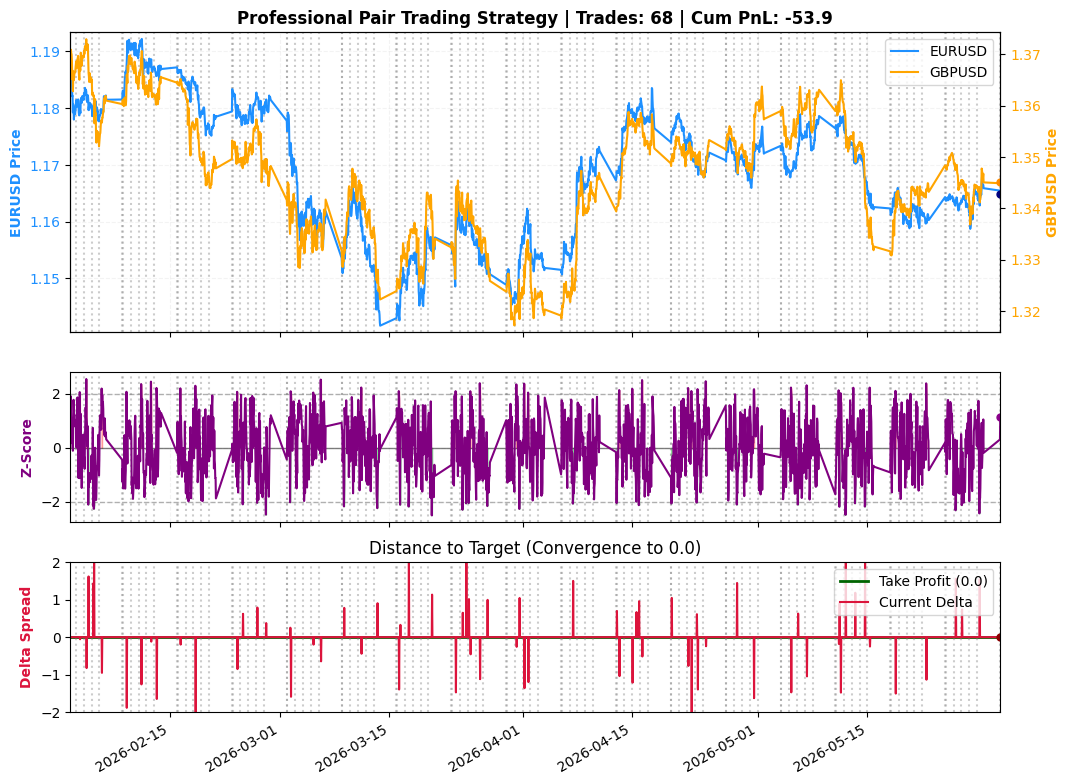

[INFO] Institutional delta backtest completed successfully.
total_trades: 68
gross_total_pnl_pips: -53.86
net_total_pnl_pips: -142.05
total_fees_paid_pips: 88.19
net_win_rate_pct: 39.71
avg_net_win_pips: 5.94
avg_net_loss_pips: -7.38
net_profit_factor: 0.53
expected_value_ev_pips: -2.089


,entry_date,exit_date,type,beta,x_entry,y_entry,x_exit,y_exit,pnl
0,2026-02-03 12:00:00,2026-02-03 13:00:00,SHORT,1.345549,1.179665,1.368200,1.179610,1.367030,0.001096
1,2026-02-04 08:00:00,2026-02-04 09:00:00,SHORT,1.205183,1.182865,1.372955,1.181400,1.370880,0.000309
2,2026-02-04 14:00:00,2026-02-04 15:00:00,LONG,0.598466,1.181515,1.368810,1.179630,1.366405,-0.001277
3,2026-02-05 05:00:00,2026-02-05 06:00:00,LONG,1.658208,1.179010,1.362015,1.179065,1.361830,-0.000276
4,2026-02-05 07:00:00,2026-02-05 08:00:00,LONG,1.582573,1.179905,1.362020,1.180300,1.360325,-0.002320
...,...,...,...,...,...,...,...,...,...
63,2026-05-18 14:00:00,2026-05-18 15:00:00,SHORT,2.381764,1.164200,1.339390,1.164855,1.341810,-0.000860
64,2026-05-22 12:00:00,2026-05-22 13:00:00,SHORT,0.224591,1.160430,1.343665,1.160385,1.343800,-0.000145
65,2026-05-26 06:00:00,2026-05-26 07:00:00,LONG,2.106302,1.163525,1.347760,1.163710,1.347485,-0.000665
66,2026-05-27 01:00:00,2026-05-27 02:00:00,LONG,1.007292,1.163395,1.344720,1.163840,1.345255,0.000087


In [178]:
start_dates = ['2026-04-05', '2026-07-12', '2021-08-22', '2020-03-08', '2020-01-05']
end_dates = ['2026-04-11', '2026-07-18', '2021-08-28', '2020-03-14', '2020-01-11']
start_date = '2026-02-01' # start_dates[-1]
end_date = '2026-06-01' # end_dates[-1]

df_eurusd = extract_m15_close_prices(
    base_path='/home/user/perso/trading/alphalab',
    symbol='EURUSD',
    start_date=start_date, # start on sunday
    end_date=end_date, # saturday excluded.
    rule='1h',
)
df_gbpusd = extract_m15_close_prices(
    base_path='/home/user/perso/trading/alphalab',
    symbol='GBPUSD',
    start_date=start_date,
    end_date=end_date,
    rule='1h',
)
df = merge_trading_pair_prices(df_eurusd, df_gbpusd)

result = compute_pair_trading_metrics(df, window=10)
report = stream_pair_trading_market(result)

metrics = calculate_real_trading_performance(report, commission_per_lot_usd=0.0)
for key, value in metrics.items():
    print(f"{key}: {value}")

report

In [169]:
import pandas as pd


def calculate_real_trading_performance(
    df_report: pd.DataFrame,
    spread_eurusd_pips: float = 0.5,
    spread_gbpusd_pips: float = 0.7,
    commission_per_lot_usd: float = 3.5,
) -> dict:
  """Computes realistic trading metrics and Expected Value directly in pips.

  Accounts for double-sided friction costs on both legs and scales the final
  performance logs using a 1e4 multiplier for standard Forex pip evaluation.

  Args:
    df_report: A pandas DataFrame containing columns: ['type', 'beta', 'pnl'].
    spread_eurusd_pips: Average broker spread for EURUSD in pips (e.g., 0.5).
    spread_gbpusd_pips: Average broker spread for GBPUSD in pips (e.g., 0.7).
    commission_per_lot_usd: ECN commission per round-turn per lot (e.g., 3.5).

  Returns:
    A dictionary populated with gross, net, fees, and EV expressed in pips.
  """
  if df_report.empty or 'pnl' not in df_report.columns:
    print("[ERROR] The trade log DataFrame is empty or invalid.")
    return {}

  total_trades = len(df_report)

  # Pip scaling multiplier for major currency pairs (1 pip = 0.0001)
  pip_multiplier = 10000.0
  pip_value = 1.0 / pip_multiplier

  net_pnls_pips = []
  total_fees_accumulated_pips = 0.0
  gross_pnl_pips_sum = 0.0

  for _, row in df_report.iterrows():
    beta = row['beta']
    gross_pnl_raw = row['pnl']

    # Position sizing constraints
    lot_y = 1.0
    lot_x = abs(beta)

    # 1. Convert structural broker spreads to pip costs
    fee_spread_y_pips = spread_gbpusd_pips * lot_y
    fee_spread_x_pips = spread_eurusd_pips * lot_x

    # 2. Convert ECN dollar commissions into pip equivalents
    # Formula: Commission / (100,000 * 0.0001) -> Commission / 10
    fee_comm_y_pips = (commission_per_lot_usd / 10.0) * 2.0 * lot_y
    fee_comm_x_pips = (commission_per_lot_usd / 10.0) * 2.0 * lot_x

    # Combine frictions for the current trade
    total_trade_fees_pips = (
        fee_spread_y_pips + fee_spread_x_pips + fee_comm_y_pips + fee_comm_x_pips
    )
    total_fees_accumulated_pips += total_trade_fees_pips

    # Convert gross PnL row to pips and subtract fees
    gross_pnl_pips = gross_pnl_raw * pip_multiplier
    gross_pnl_pips_sum += gross_pnl_pips

    net_pnls_pips.append(gross_pnl_pips - total_trade_fees_pips)

  # 3. Analyze Net metrics series in pip units
  net_series_pips = pd.Series(net_pnls_pips)

  net_wins_pips = net_series_pips[net_series_pips > 0]
  net_losses_pips = net_series_pips[net_series_pips <= 0]

  total_net_wins = len(net_wins_pips)
  total_net_losses = len(net_losses_pips)

  # 4. Compute mathematical Expected Value (EV) per trade in pips
  win_prob = total_net_wins / total_trades if total_trades > 0 else 0.0
  loss_prob = total_net_losses / total_trades if total_trades > 0 else 0.0

  avg_net_win_pips = net_wins_pips.mean() if total_net_wins > 0 else 0.0
  avg_net_loss_pips = net_losses_pips.mean() if total_net_losses > 0 else 0.0

  expected_value_pips = (win_prob * avg_net_win_pips) + (
      loss_prob * avg_net_loss_pips
  )

  # 5. Compute structural Net Profit Factor
  sum_net_wins = net_wins_pips.sum()
  sum_net_losses = abs(net_losses_pips.sum())
  net_profit_factor = (
      sum_net_wins / sum_net_losses if sum_net_losses > 0 else float('inf')
  )

  # Package final metrics report in pips
  report = {
      'total_trades': total_trades,
      'gross_total_pnl_pips': round(gross_pnl_pips_sum, 2),
      'net_total_pnl_pips': round(net_series_pips.sum(), 2),
      'total_fees_paid_pips': round(total_fees_accumulated_pips, 2),
      'net_win_rate_pct': round((total_net_wins / total_trades) * 100, 2),
      'avg_net_win_pips': round(avg_net_win_pips, 2),
      'avg_net_loss_pips': round(avg_net_loss_pips, 2),
      'net_profit_factor': round(net_profit_factor, 2),
      'expected_value_ev_pips': round(expected_value_pips, 4),
  }

  return report


In [170]:
metrics = calculate_real_trading_performance(report, commission_per_lot_usd=0.0)
for key, value in metrics.items():
    print(f"{key}: {value}")


total_trades: 7
gross_total_pnl_pips: 10.94
net_total_pnl_pips: -1.37
total_fees_paid_pips: 12.31
net_win_rate_pct: 57.14
avg_net_win_pips: 1.84
avg_net_loss_pips: -2.91
net_profit_factor: 0.84
expected_value_ev_pips: -0.195


In [188]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    df_sorted_losses = report.sort_values(by='pnl', ascending=False).copy()
    df_sorted_losses['pnl'] = (df_sorted_losses['pnl'] * 10000.0).round(1)
    display.display(df_sorted_losses)

,entry_date,exit_date,type,beta,x_entry,y_entry,x_exit,y_exit,pnl
57,2026-05-11 10:00:00,2026-05-11 11:00:00,LONG,0.837259,1.176915,1.358850,1.176840,1.360710,19.2
12,2026-02-23 14:00:00,2026-02-23 15:00:00,SHORT,0.913206,1.180545,1.352080,1.179480,1.349475,16.3
8,2026-02-12 14:00:00,2026-02-12 15:00:00,SHORT,1.468631,1.188330,1.366460,1.188575,1.365400,14.2
62,2026-05-15 07:00:00,2026-05-15 08:00:00,SHORT,1.388341,1.163660,1.336435,1.163300,1.334590,13.5
50,2026-04-24 09:00:00,2026-04-24 10:00:00,SHORT,1.325655,1.168650,1.348265,1.170325,1.349235,12.5
24,2026-03-16 09:00:00,2026-03-16 10:00:00,LONG,0.498110,1.145010,1.324755,1.147540,1.327250,12.3
15,2026-02-27 06:00:00,2026-02-27 07:00:00,LONG,0.676216,1.180440,1.346965,1.181510,1.348795,11.1
0,2026-02-03 12:00:00,2026-02-03 13:00:00,SHORT,1.345549,1.179665,1.368200,1.179610,1.367030,11.0
34,2026-03-31 05:00:00,2026-03-31 06:00:00,SHORT,1.709579,1.146445,1.320200,1.147210,1.320550,9.6
16,2026-03-02 08:00:00,2026-03-02 09:00:00,LONG,1.244604,1.172245,1.335030,1.173310,1.337265,9.1
